编程程序，爬取综合新闻https://news.swufe.edu.cn/zhxw.htm 中的所有新闻详情，并利用详情制作词云。注意，请将你的名字加入到词云图中，并且用最大
的字体显示。


西南财经大学综合新闻爬取与词云生成
正在访问新闻列表页: https://news.swufe.edu.cn/zhxw.htm
找到 40 条新闻链接

将爬取前 20 条新闻

[1/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115811.htm
成功获取内容，长度: 691 字符

[2/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115801.htm
成功获取内容，长度: 678 字符

[3/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115781.htm
成功获取内容，长度: 556 字符

[4/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115791.htm
成功获取内容，长度: 628 字符

[5/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115771.htm
成功获取内容，长度: 725 字符

[6/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115751.htm
成功获取内容，长度: 570 字符

[7/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115741.htm
成功获取内容，长度: 359 字符

[8/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115731.htm
成功获取内容，长度: 817 字符

[9/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115681.htm
成功获取内容，长度: 550 字符

[10/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115671.htm
成功获取内容，长度: 732 字符

[11/20] 正在爬取: https://news.swufe.edu.cn/info/1003/115661.htm
成功获取内容，长度: 640 字符

[12/20] 正在爬取: https://news.swufe.edu.cn

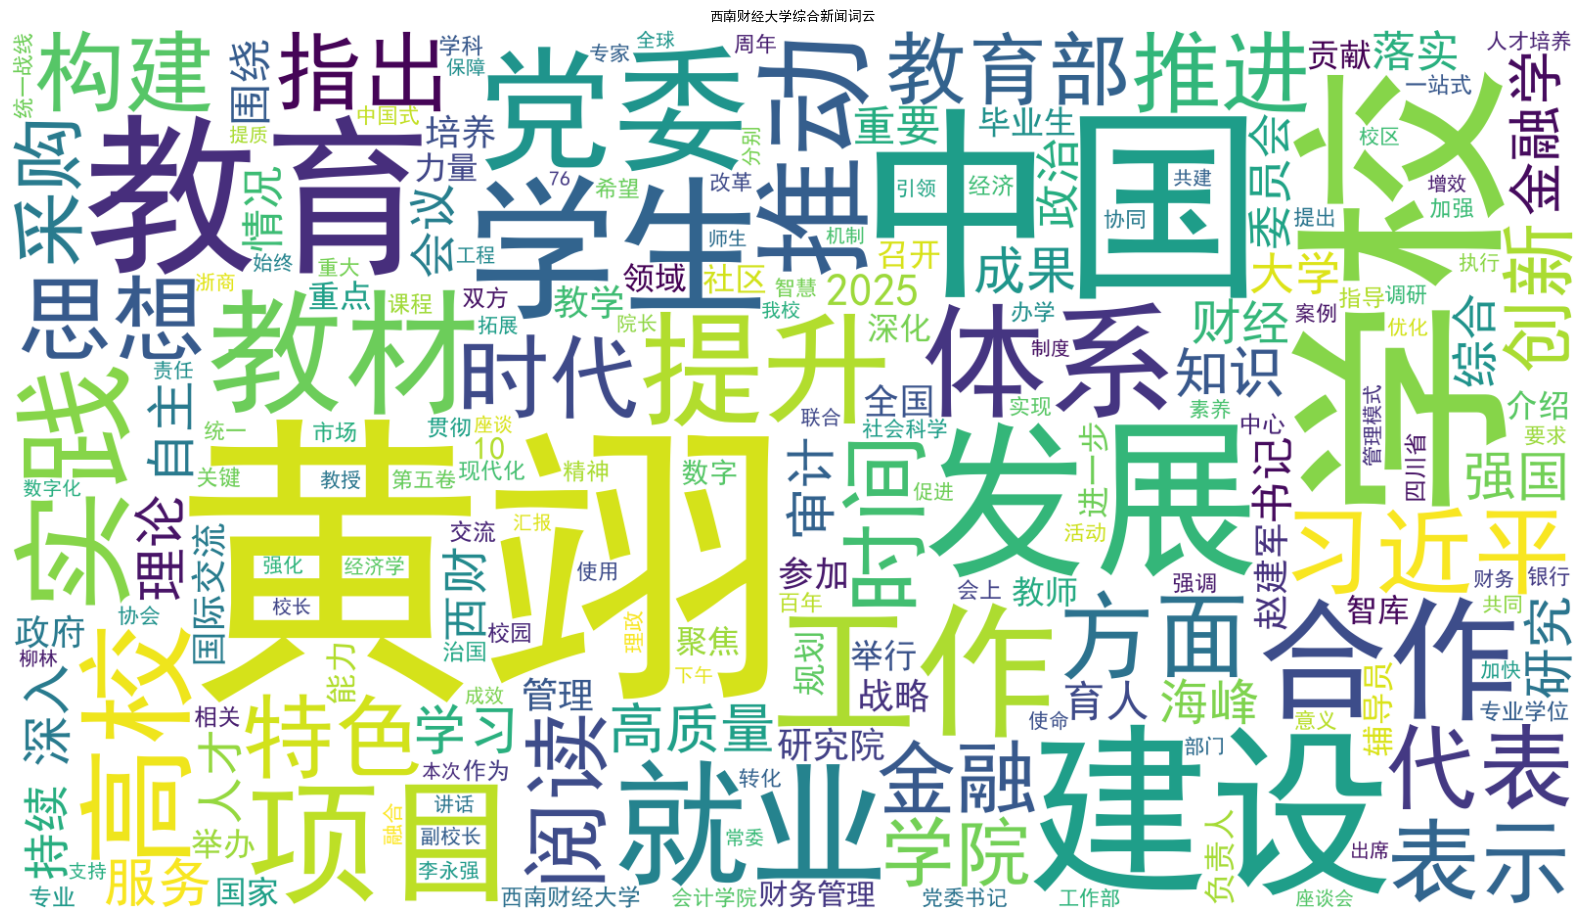


程序执行完成！


'\n1. 需要安装的依赖包：\n   pip install requests beautifulsoup4 jieba wordcloud matplotlib\n\n2. 字体文件：\n   - Windows: 通常自带simhei.ttf（黑体）\n   - macOS: 可能需要指定其他字体路径\n   - Linux: 需要安装中文字体包\n\n3. 如果遇到字体问题，可以：\n   - 下载字体文件放在程序同目录\n   - 或修改font_path参数指向正确的字体路径\n\n4. 网络问题：\n   - 如果爬取失败，可能是网络问题或网站结构变化\n   - 可以调整headers或增加重试机制\n\n5. 爬虫礼仪：\n   - 程序已添加延迟(time.sleep)避免过度请求\n   - 限制了爬取数量\n   - 请遵守网站的robots.txt规则\n'

In [ ]:
"""
综合新闻爬取与词云生成
"""

import requests
from bs4 import BeautifulSoup
import jieba
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re
import time


def get_news_list(url):
    """
    获取新闻列表页面的所有新闻链接
    """
    print(f"正在访问新闻列表页: {url}")
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.encoding = 'utf-8'
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # 查找所有新闻链接（根据网站结构调整选择器）
        news_links = []
        
        # 方法1：查找所有包含链接的li标签
        for link in soup.select('li a[href]'):
            href = link.get('href')
            if href and 'info' in href:  # 通常详情页包含info
                # 处理相对路径
                if not href.startswith('http'):
                    base_url = 'https://news.swufe.edu.cn/'
                    href = base_url + href.lstrip('./')
                news_links.append(href)
        
        print(f"找到 {len(news_links)} 条新闻链接")
        return news_links
    
    except Exception as e:
        print(f"获取新闻列表失败: {e}")
        return []


def get_news_content(url):
    """
    获取单条新闻的详细内容
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.encoding = 'utf-8'
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # 尝试多种方式提取正文内容
        content = ''
        
        # 方法1：查找class包含content的div
        content_div = soup.find('div', class_=re.compile('content|article|newsContent'))
        if content_div:
            content = content_div.get_text(strip=True)
        
        # 方法2：查找id包含content的div
        if not content:
            content_div = soup.find('div', id=re.compile('content|article'))
            if content_div:
                content = content_div.get_text(strip=True)
        
        # 方法3：查找所有p标签
        if not content:
            paragraphs = soup.find_all('p')
            content = ' '.join([p.get_text(strip=True) for p in paragraphs])
        
        return content
    
    except Exception as e:
        print(f"获取新闻内容失败 {url}: {e}")
        return ''


def process_text(text):
    """
    文本预处理和分词
    """
    # 移除标点符号和特殊字符
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    
    # 使用jieba分词
    words = jieba.cut(text)
    
    # 过滤停用词
    stopwords = set([
        '的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一',
        '一个', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有',
        '看', '好', '自己', '这', '为', '与', '及', '等', '个', '中', '大', '来',
        '对', '于', '将', '可以', '并', '以', '但', '年', '月', '日', '进行', '通过'
    ])
    
    # 过滤掉停用词和单字词
    filtered_words = [
        word for word in words 
        if word not in stopwords and len(word) > 1
    ]
    
    return filtered_words


def create_wordcloud(words, output_file='wordcloud.png'):
    """
    创建词云图
    """
    # 统计词频
    word_freq = Counter(words)
    
    # 强制添加""并设置最高频率
    max_freq = max(word_freq.values()) if word_freq else 100
    word_freq[''] = max_freq * 2  # 设置为最高频率的2倍
    
    print(f"\n词频统计（前20）:")
    for word, freq in word_freq.most_common(20):
        print(f"{word}: {freq}")
    
    # 生成词云
    wordcloud = WordCloud(
        font_path='simhei.ttf',  # 使用黑体，Windows下通常在C:/Windows/Fonts/
        # 如果没有simhei.ttf，可以尝试：
        # font_path='/System/Library/Fonts/STHeiti Light.ttc',  # macOS
        # font_path='/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc',  # Linux
        width=1600,
        height=900,
        background_color='white',
        max_words=200,
        relative_scaling=0.5,
        colormap='viridis'
    ).generate_from_frequencies(word_freq)
    
    # 显示词云
    plt.figure(figsize=(16, 9))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('综合新闻词云', fontsize=20, fontproperties='SimHei')
    plt.tight_layout(pad=0)
    
    # 保存图片
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n词云已保存到: {output_file}")
    
    plt.show()


def main():
    """
    主函数
    """
    print("=" * 60)
    print("综合新闻爬取与词云生成")
    print("=" * 60)
    
    # 1. 获取新闻列表
    list_url = 'https://news.swufe.edu.cn/zhxw.htm'
    news_links = get_news_list(list_url)
    
    if not news_links:
        print("未找到新闻链接，程序退出")
        return
    
    # 限制爬取数量（避免过度请求）
    max_news = min(20, len(news_links))
    print(f"\n将爬取前 {max_news} 条新闻")
    
    # 2. 爬取新闻内容
    all_content = []
    for i, link in enumerate(news_links[:max_news], 1):
        print(f"\n[{i}/{max_news}] 正在爬取: {link}")
        content = get_news_content(link)
        if content:
            all_content.append(content)
            print(f"成功获取内容，长度: {len(content)} 字符")
        
        # 延迟，避免请求过快
        time.sleep(0.2)
    
    if not all_content:
        print("\n未获取到任何新闻内容")
        return
    
    # 3. 合并所有内容
    full_text = ' '.join(all_content)
    print(f"\n总共获取 {len(all_content)} 条新闻")
    print(f"总字符数: {len(full_text)}")
    
    # 4. 分词处理
    print("\n正在进行分词...")
    words = process_text(full_text)
    print(f"分词完成，共 {len(words)} 个词")
    
    # 5. 生成词云
    print("\n正在生成词云...")
    create_wordcloud(words)
    
    print("\n" + "=" * 60)
    print("程序执行完成！")
    print("=" * 60)


if __name__ == '__main__':
    main()


# ============= 注意事项 =============
"""
1. 需要安装的依赖包：
   pip install requests beautifulsoup4 jieba wordcloud matplotlib

2. 字体文件：
   - Windows: 通常自带simhei.ttf（黑体）
   - macOS: 可能需要指定其他字体路径
   - Linux: 需要安装中文字体包

3. 如果遇到字体问题，可以：
   - 下载字体文件放在程序同目录
   - 或修改font_path参数指向正确的字体路径

4. 网络问题：
   - 如果爬取失败，可能是网络问题或网站结构变化
   - 可以调整headers或增加重试机制

5. 爬虫礼仪：
   - 程序已添加延迟(time.sleep)避免过度请求
   - 限制了爬取数量
   - 请遵守网站的robots.txt规则
"""